<a href="https://colab.research.google.com/github/adilah-annisa/Quiz_Adilah/blob/main/AdilahAnnisa_Pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Persiapan Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_mahasiswa.xlsx to data_mahasiswa.xlsx


In [ ]:
# Percobaan 2 (Memuat Data & Eksplorasi Awal (EDA))
df = pd.read_excel('data_mahasiswa.xlsx')

print('Ukuran dataset:', df.shape)
df.head()

Ukuran dataset: (1005, 16)


,student_id,gender,age,study_program,semester,attendance_pct,assignment_score,midterm_score,final_score,study_hours_week,lms_activity_pct,sleep_hours,gpa,device,internet_quota_gb,status
0,2304899,Laki-laki,19,Animasi,3,81.63,91.84,60.53,67.21,NaN,83.07,7.19,3.18,Laptop,11.61,Lulus
1,2502152,Laki-laki,17,Sistem Informasi,1,80.20,71.05,96.14,79.13,7.60,49.55,7.71,3.61,Laptop,29.90,Lulus
2,2101251,Laki-laki,20,Teknik Informatika,6,95.37,93.39,75.45,64.26,5.39,71.52,7.80,3.99,Laptop,17.32,Lulus
3,2004863,Perempuan,22,Animasi,7,88.73,86.09,72.10,42.25,5.61,74.62,6.56,2.89,Laptop,30.72,Tidak Lulus
4,2001784,Laki-laki,21,Teknik Informatika,8,89.08,93.59,69.36,72.37,3.53,82.03,8.07,3.52,Laptop,31.03,Lulus


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         1005 non-null   int64  
 1   gender             1005 non-null   object 
 2   age                1005 non-null   int64  
 3   study_program      1005 non-null   object 
 4   semester           1005 non-null   int64  
 5   attendance_pct     985 non-null    float64
 6   assignment_score   985 non-null    float64
 7   midterm_score      985 non-null    float64
 8   final_score        1005 non-null   float64
 9   study_hours_week   985 non-null    float64
 10  lms_activity_pct   985 non-null    float64
 11  sleep_hours        1005 non-null   float64
 12  gpa                1005 non-null   float64
 13  device             1005 non-null   object 
 14  internet_quota_gb  1005 non-null   float64
 15  status             1005 non-null   object 
dtypes: float64(9), int64(3),

In [ ]:
df.describe()

,student_id,age,semester,attendance_pct,assignment_score,midterm_score,final_score,study_hours_week,lms_activity_pct,sleep_hours,gpa,internet_quota_gb
count,1.005000e+03,1005.000000,1005.000000,985.000000,985.000000,985.000000,1005.000000,985.00000,985.000000,1005.000000,1005.000000,1005.000000
mean,2.231683e+06,19.998010,4.379104,86.930457,78.441990,71.341442,73.727781,5.66197,66.911330,6.727881,3.393353,23.639781
std,6.497557e+05,1.271037,2.303332,8.219594,10.934668,12.904951,12.615100,3.33616,13.192335,0.977646,0.339206,12.566852
min,2.001009e+06,17.000000,1.000000,57.160000,40.000000,35.000000,35.000000,1.00000,25.000000,4.000000,1.950000,5.000000
25%,2.101249e+06,19.000000,2.000000,81.320000,70.810000,62.330000,65.040000,3.23000,57.970000,6.110000,3.170000,14.220000
50%,2.201496e+06,20.000000,4.000000,87.010000,78.670000,71.410000,73.570000,4.96000,66.470000,6.720000,3.400000,20.890000
75%,2.401453e+06,21.000000,6.000000,93.090000,86.270000,80.320000,82.460000,7.39000,75.780000,7.380000,3.610000,30.450000
max,2.204100e+07,23.000000,8.000000,100.000000,100.000000,100.000000,100.000000,20.00000,100.000000,9.660000,4.000000,60.000000


In [ ]:
# Percobaan 3 (Data Cleaning)
# 1. Pengecekan Missing Value
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({
  'jumlah_missing': missing,
  'persentase(%)': missing_pct
}).query('jumlah_missing > 0')

,jumlah_missing,persentase(%)
attendance_pct,20,1.99
assignment_score,20,1.99
midterm_score,20,1.99
study_hours_week,20,1.99
lms_activity_pct,20,1.99


In [ ]:
kolom_numerik_missing  = ['attendance_pct', 'assignment_score','midterm_score',
                          'study_hours_week','lms_activity_pct']

for kolom in kolom_numerik_missing:
  median_value = df[kolom].median()
  df[kolom] = df[kolom].fillna(median_value)
  print(f'{kolom:20s} -> diisi dengan median = {median_value}')

# Verifikasi tidak ada lagi missing value
print('\nTotal missing value setelah imputasi:', df.isna(),sum().sum())

attendance_pct       -> diisi dengan median = 87.01
assignment_score     -> diisi dengan median = 78.67
midterm_score        -> diisi dengan median = 71.41
study_hours_week     -> diisi dengan median = 4.96
lms_activity_pct     -> diisi dengan median = 66.47


TypeError: sum() takes at least 1 positional argument (0 given)

In [ ]:
# 2. Pengecekan Data Duplikat
print('Jumlah baris duplikat penuh:', df.duplicated().sum())
print('Jumlah student_id duplikat   :', df['student_id'].duplicated().sum())

df[df.duplicated(keep=False)].sort_values('student_id')

Jumlah baris duplikat penuh: 5
Jumlah student_id duplikat   : 5


,student_id,gender,age,study_program,semester,attendance_pct,assignment_score,midterm_score,final_score,study_hours_week,lms_activity_pct,sleep_hours,gpa,device,internet_quota_gb,status
507,2001051,Laki-laki,22,Teknik Informatika,8,74.77,67.63,63.54,35.00,4.33,53.58,5.39,2.34,Laptop,17.51,Tidak Lulus
356,2001051,Laki-laki,22,Teknik Informatika,8,74.77,67.63,63.54,35.00,4.33,53.58,5.39,2.34,Laptop,17.51,Tidak Lulus
38,2001204,Laki-laki,21,Teknik Informatika,7,97.78,89.59,70.54,92.54,3.57,82.10,7.76,3.77,Smartphone,15.29,Lulus
93,2001204,Laki-laki,21,Teknik Informatika,7,97.78,89.59,70.54,92.54,3.57,82.10,7.76,3.77,Smartphone,15.29,Lulus
553,2004139,Laki-laki,21,Animasi,7,79.37,83.47,50.34,72.74,4.92,67.09,8.09,3.17,Laptop,23.43,Lulus
74,2004139,Laki-laki,21,Animasi,7,79.37,83.47,50.34,72.74,4.92,67.09,8.09,3.17,Laptop,23.43,Lulus
80,2202586,Laki-laki,19,Sistem Informasi,4,77.07,89.59,82.69,99.28,2.57,87.20,5.25,3.95,Laptop,16.28,Lulus
345,2202586,Laki-laki,19,Sistem Informasi,4,77.07,89.59,82.69,99.28,2.57,87.20,5.25,3.95,Laptop,16.28,Lulus
633,2203132,Laki-laki,21,Teknik Rekayasa Komputer,4,81.06,61.98,81.90,79.71,12.57,57.27,6.20,3.61,Smartphone,10.03,Lulus
637,2203132,Laki-laki,21,Teknik Rekayasa Komputer,4,81.06,61.98,81.90,79.71,12.57,57.27,6.20,3.61,Smartphone,10.03,Lulus


In [ ]:
# Menampilkan jumlah baris duplikat yang dihapus
jumlah_sebelum = len(df)
df = df.drop_duplicates(subset='student_id',keep='first').reset_index(drop=True)
jumlah_sesudah = len(df)

print(f'Jumlah baris sebelum: {jumlah_sebelum}')
print(f'Jumlah baris sesudah: {jumlah_sesudah}')
print(f'Baris yang dihapus: {jumlah_sebelum - jumlah_sesudah}')

Jumlah baris sebelum: 1005
Jumlah baris sesudah: 1000
Baris yang dihapus: 5


In [ ]:
# 3. Memeriksa Outlier
df['student_id'].describe()

,student_id
count,1.000000e+03
mean,2.232430e+06
std,6.512565e+05
min,2.001009e+06
25%,2.101256e+06
50%,2.201499e+06
75%,2.401474e+06
max,2.204100e+07


In [ ]:
# Perbaikan NIM yang salah ketik (kelebihan satu digit) -> dari 22041000 menjadi 2204100
df.loc[df['student_id'] > 1e7, 'student_id'] = df.loc[df['student_id'] > 1e7, 'student_id']

df['student_id'].describe()

,student_id
count,1.000000e+03
mean,2.232430e+06
std,6.512565e+05
min,2.001009e+06
25%,2.101256e+06
50%,2.201499e+06
75%,2.401474e+06
max,2.204100e+07


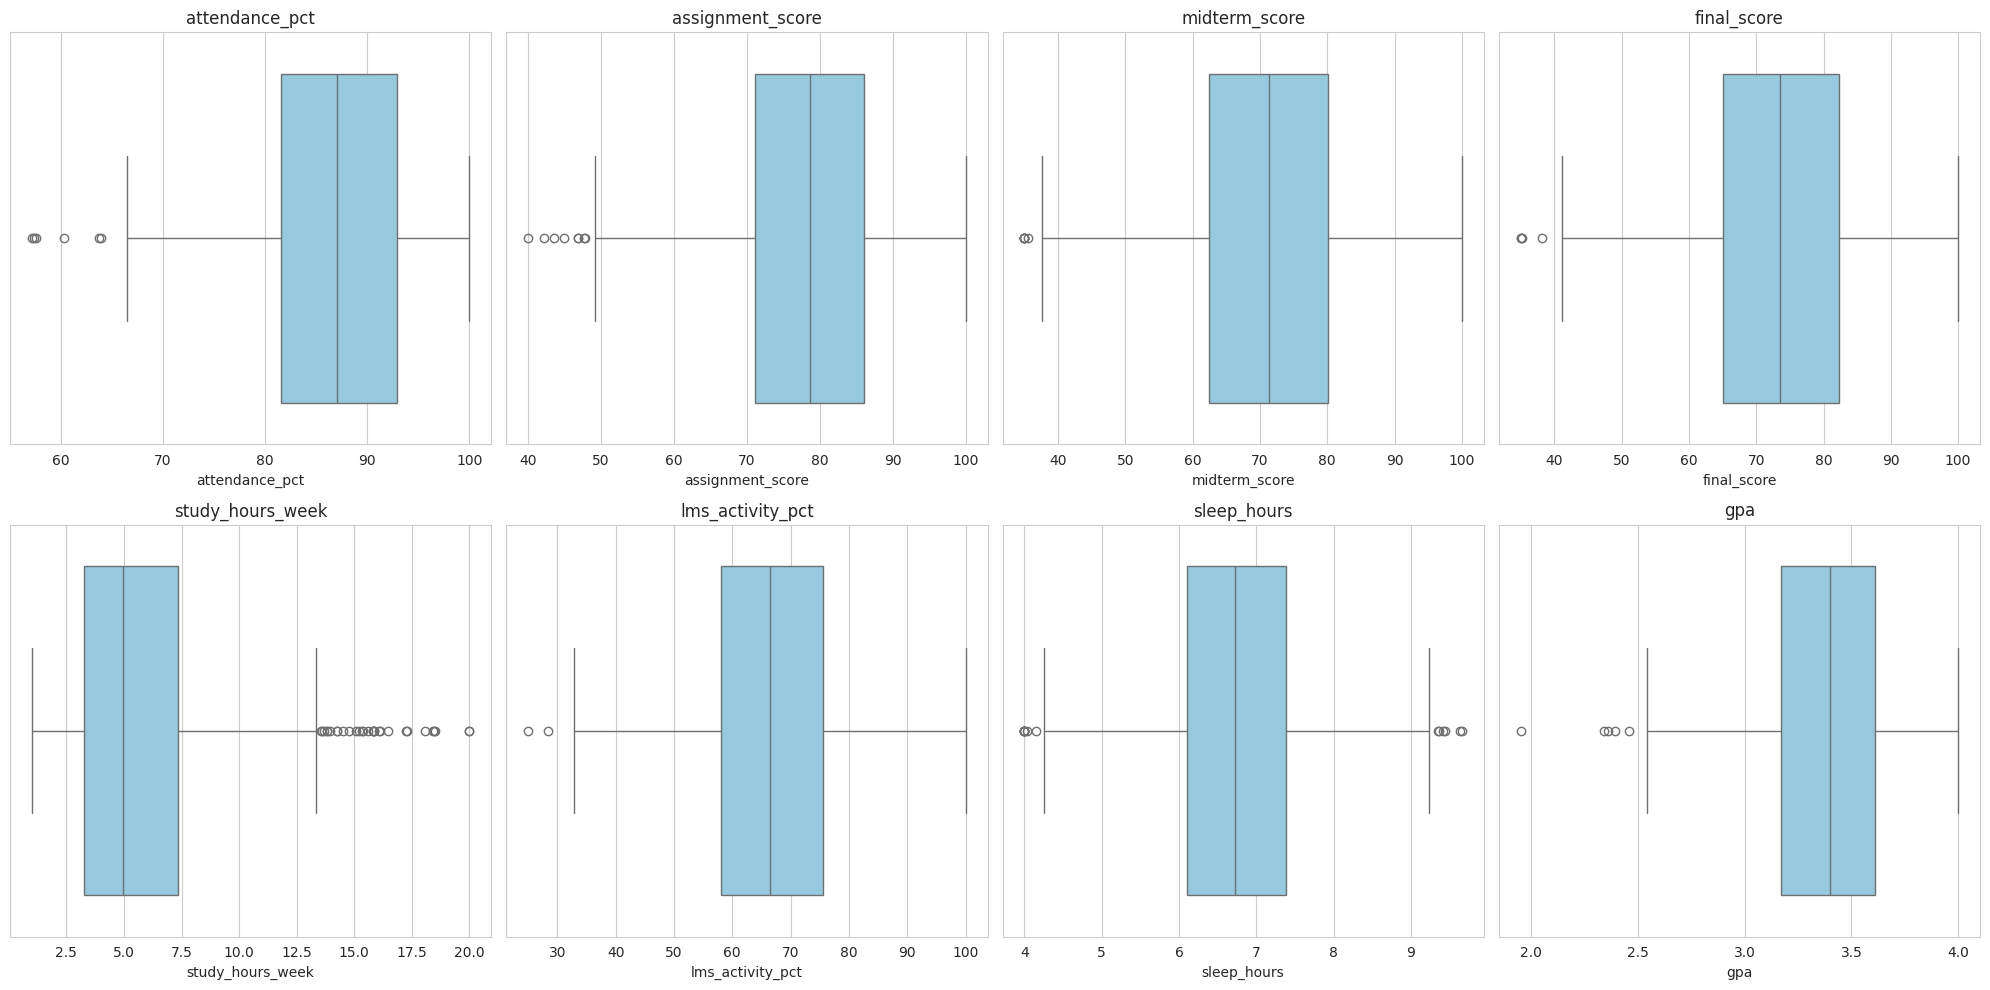

In [ ]:
# Outlier pada kolom numerik (Visualisasi Boxplot)
kolom_numerik = ['attendance_pct', 'assignment_score','midterm_score', 'final_score',
                 'study_hours_week','lms_activity_pct', 'sleep_hours', 'gpa']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, kolom in zip(axes.flatten(), kolom_numerik):
  sns.boxplot(x=df[kolom], ax=ax, color='skyblue')
  ax.set_title(kolom)
plt.tight_layout()
plt.show()

In [ ]:
# Mendeteksi outlier menggunakan metode IQR (Interquartile Range)
def deteksi_outlier_iqr (kolom):
  Q1 = df[kolom].quantile(0.25)
  Q3 = df[kolom].quantile(0.75)
  IQR = Q3 - Q1
  batas_bawah = Q1 - 1.5 * IQR
  batas_atas = Q3 + 1.5 * IQR

  outlier = df[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas)]
  print(f'{kolom:20s} | batas: {batas_bawah:8.2f}, {batas_atas:8.2f} | jumlah_outlier: {len(outlier)}')
  return batas_bawah, batas_atas

for kolom in kolom_numerik:
  deteksi_outlier_iqr(kolom)

attendance_pct       | batas:    64.45,   109.93 | jumlah_outlier: 6
assignment_score     | batas:    48.78,   108.43 | jumlah_outlier: 8
midterm_score        | batas:    36.05,   106.52 | jumlah_outlier: 6
final_score          | batas:    39.06,   108.29 | jumlah_outlier: 4
study_hours_week     | batas:    -2.82,    13.44 | jumlah_outlier: 30
lms_activity_pct     | batas:    31.80,   101.92 | jumlah_outlier: 2
sleep_hours          | batas:     4.21,     9.29 | jumlah_outlier: 14
gpa                  | batas:     2.51,     4.27 | jumlah_outlier: 5


In [ ]:
# Teknik Capping (Winsorizing)
batas_bawah, batas_atas = deteksi_outlier_iqr('study_hours_week')

sebelum = (df['study_hours_week'] > batas_atas).sum()
df['study_hours_week'] = np.where(df['study_hours_week'] > batas_atas, batas_atas, df['study_hours_week'])

print(f'Jumlah nilai yang di-cap: {sebelum}')
df['study_hours_week'].describe()

study_hours_week     | batas:    -2.82,    13.44 | jumlah_outlier: 30
Jumlah nilai yang di-cap: 30


,study_hours_week
count,1000.000000
mean,5.574855
std,3.078425
min,1.000000
25%,3.280000
50%,4.960000
75%,7.345000
max,13.442500


In [ ]:
# Percobaan 4 (Memeriksa Konsistensi Data Kategorikal)
kolom_kategorikal= ['gender', 'study_program', 'device', 'status']

for kolom in kolom_kategorikal:
  print(f'{kolom}: {sorted(df[kolom].unique())}')

gender: ['Laki-laki', 'Perempuan']
study_program: ['Animasi', 'Sistem Informasi', 'Teknik Informatika', 'Teknik Rekayasa Komputer']
device: ['Laptop', 'PC Desktop', 'Smartphone', 'Tablet']
status: ['Lulus', 'Tidak Lulus']


In [ ]:
# Percobaan 5 (Data Transformation)
# 1. Encoding Data Kategorikal (Label Encoding untuk kolom biner)
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])
print('gender   :', dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

le_status = LabelEncoder()
df['status_encoded'] = le_status.fit_transform(df['status'])
print('status   :', dict(zip(le_status.classes_, le_status.transform(le_status.classes_))))

df[['gender', 'gender_encoded', 'status', 'status_encoded']].head()

gender   : {'Laki-laki': np.int64(0), 'Perempuan': np.int64(1)}
status   : {'Lulus': np.int64(0), 'Tidak Lulus': np.int64(1)}


,gender,gender_encoded,status,status_encoded
0,Laki-laki,0,Lulus,0
1,Laki-laki,0,Lulus,0
2,Laki-laki,0,Lulus,0
3,Perempuan,1,Tidak Lulus,1
4,Laki-laki,0,Lulus,0


In [ ]:
# One-Hot Encoding untuk kolom nominal (>2 kategori)
df = pd.get_dummies(df, columns=['study_program', 'device'], prefix=['prodi', 'device'])

df.filter(regex='prodi_|device_').head()

,prodi_Animasi,prodi_Sistem Informasi,prodi_Teknik Informatika,prodi_Teknik Rekayasa Komputer,device_Laptop,device_PC Desktop,device_Smartphone,device_Tablet
0,True,False,False,False,True,False,False,False
1,False,True,False,False,True,False,False,False
2,False,False,True,False,True,False,False,False
3,True,False,False,False,True,False,False,False
4,False,False,True,False,True,False,False,False


In [ ]:
# 2. Scaling (Normalisasi Fitur Numerik)
kolom_untuk_scaling = ['attendance_pct', 'assignment_score','midterm_score', 'final_score',
                         'study_hours_week','lms_activity_pct', 'sleep_hours', 'internet_quota_gb']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[kolom_untuk_scaling])

kolom_scaled = [f'{k}_scaled' for k in kolom_untuk_scaling]
df[kolom_scaled] = df_scaled

df[kolom_untuk_scaling + kolom_scaled].head()

,attendance_pct,assignment_score,midterm_score,final_score,study_hours_week,lms_activity_pct,sleep_hours,internet_quota_gb,attendance_pct_scaled,assignment_score_scaled,midterm_score_scaled,final_score_scaled,study_hours_week_scaled,lms_activity_pct_scaled,sleep_hours_scaled,internet_quota_gb_scaled
0,81.63,91.84,60.53,67.21,4.96,83.07,7.19,11.61,-0.655537,1.238266,-0.847189,-0.518941,-0.199830,1.239711,0.472544,-0.959239
1,80.20,71.05,96.14,79.13,7.60,49.55,7.71,29.90,-0.831524,-0.683827,1.940887,0.431671,0.658180,-1.328562,1.005369,0.494871
2,95.37,93.39,75.45,64.26,5.39,71.52,7.80,17.32,1.035410,1.381567,0.320969,-0.754201,-0.060079,0.354760,1.097589,-0.505277
3,88.73,86.09,72.10,42.25,5.61,74.62,6.56,30.72,0.218242,0.706662,0.058681,-2.509484,0.011422,0.592280,-0.172994,0.560064
4,89.08,93.59,69.36,72.37,3.53,82.03,8.07,31.03,0.261315,1.400058,-0.155846,-0.107434,-0.664586,1.160027,1.374248,0.584710


In [ ]:
# 3. Binning (Diskretisasi)
df['attendance_category'] = pd.cut(
    df['attendance_pct'],
    bins=[0, 40, 60, 100],
    labels=['low', 'medium', 'high'],
    include_lowest=True
)

df[['attendance_pct', 'attendance_category']].head(10)

,attendance_pct,attendance_category
0,81.63,high
1,80.20,high
2,95.37,high
3,88.73,high
4,89.08,high
5,91.46,high
6,81.88,high
7,85.20,high
8,100.00,high
9,78.31,high


In [ ]:
df['attendance_category'].value_counts().sort_index()

,count
attendance_category,
low,0
medium,3
high,997


In [ ]:
# Percobaan 6 (Feature Engineering)
# 1. Rata_Rata Nilai Akademik
df['average_score'] = (df['assignment_score'] * 0.2 +
                         df['midterm_score'] * 0.3 +
                         df['final_score'] * 0.5
)

df[['assignment_score', 'midterm_score', 'final_score', 'average_score']].head()

,assignment_score,midterm_score,final_score,average_score
0,91.84,60.53,67.21,70.132
1,71.05,96.14,79.13,82.617
2,93.39,75.45,64.26,73.443
3,86.09,72.10,42.25,59.973
4,93.59,69.36,72.37,75.711


In [ ]:
# 2. Efisiensi Belajar
df['study_efficiency'] = df['average_score'] / (df['study_hours_week'] + 1)

df[['average_score', 'study_hours_week', 'study_efficiency']].head()

,average_score,study_hours_week,study_efficiency
0,70.132,4.96,11.767114
1,82.617,7.60,9.606628
2,73.443,5.39,11.493427
3,59.973,5.61,9.073071
4,75.711,3.53,16.713245


In [ ]:
# 3. Indeks Keterlibatan
df['engagement_index'] = (df['attendance_pct'] * df['lms_activity_pct']) / 2

df[['attendance_pct', 'lms_activity_pct', 'engagement_index']].head()

,attendance_pct,lms_activity_pct,engagement_index
0,81.63,83.07,3390.50205
1,80.20,49.55,1986.95500
2,95.37,71.52,3410.43120
3,88.73,74.62,3310.51630
4,89.08,82.03,3653.61620


In [ ]:
# 4. Kelompok Usia
df['age_group'] = pd.cut(
    df['age'],
    bins=[16, 18, 20, 22, 25],
    labels=['under 18', '18-20', '21-22', '23+'],
)

df[['age', 'age_group']].head()

,age,age_group
0,19,18-20
1,17,under 18
2,20,18-20
3,22,21-22
4,21,21-22


In [ ]:
# 5. Kategori Kualitas Tidur
def kategori_tidur(jam):
    if jam < 6:
       return 'Kurang'
    elif jam <= 9:
        return 'Cukup'
    else:
       return 'Lebih'

df['sleep_quality'] = df['sleep_hours'].apply(kategori_tidur)

df[['sleep_hours', 'sleep_quality']].head()

,sleep_hours,sleep_quality
0,7.19,Cukup
1,7.71,Cukup
2,7.80,Cukup
3,6.56,Cukup
4,8.07,Cukup


In [ ]:
# 6. Target Biner Final
df['is_lulus'] = (df['status'] == 'Lulus').astype(int)
df[['status', 'is_lulus']].head()

,status,is_lulus
0,Lulus,1
1,Lulus,1
2,Lulus,1
3,Tidak Lulus,0
4,Lulus,1


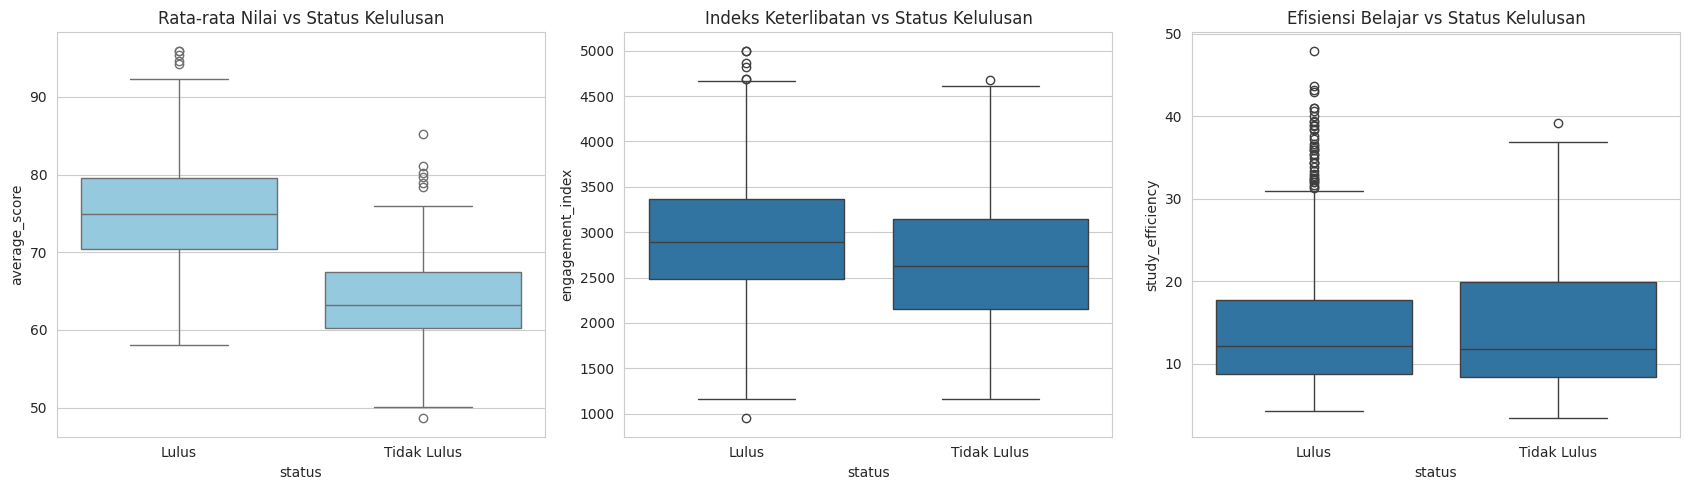

In [ ]:
# Manfaat dari feature engineering
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(data=df, x='status', y='average_score', ax=axes[0], color='skyblue')
axes[0].set_title('Rata-rata Nilai vs Status Kelulusan')


sns.boxplot(data=df, x='status', y='engagement_index', ax=axes[1])
axes[1].set_title('Indeks Keterlibatan vs Status Kelulusan')


sns.boxplot(data=df, x='status', y='study_efficiency', ax=axes[2])
axes[2].set_title('Efisiensi Belajar vs Status Kelulusan')

plt.tight_layout()
plt.show()

In [ ]:
# 7. Menyimpan Dataset Hasil Preprocessing
df.to_csv('data_mahasiswa_clean.csv', index=False)
print('Dataset berhasil disimpan sebagai data_mahasiswa_clean.csv')
print('Ukuran akhir dataset:', df.shape)

from google.colab import files
files.download('data_mahasiswa_clean.csv')

Dataset berhasil disimpan sebagai data_mahasiswa_clean.csv
Ukuran akhir dataset: (1000, 39)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Latihan 1 (Data Cleaning - Deteksi Outlier pake Z-score)
# Z-Score
mean_gpa = df['gpa'].mean()
std_gpa = df['gpa'].std()

df['gpa_zscore'] = (df['gpa'] - mean_gpa) / std_gpa

outlier_zscore = df[df['gpa'].abs() > 3]

# IQR
Q1 = df['gpa'].quantile(0.25)
Q3 = df['gpa'].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier_iqr = df[
    (df['gpa'] < batas_bawah) |
    (df['gpa'] > batas_atas)
]

print("Jumlah outlier Z-Score:", len(outlier_zscore))
print("Jumlah outlier IQR     :", len(outlier_iqr))


Jumlah outlier Z-Score: 870
Jumlah outlier IQR     : 5


In [ ]:
# Latihan 2 (Data Transformation)
# Scaling (MinMaxScaler)
kolom_untuk_scaling = ['gpa', 'internet_quota_gb']

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[kolom_untuk_scaling])

kolom_scaled = [f'{k}_scaled' for k in kolom_untuk_scaling]
df[kolom_scaled] = df_scaled

df[kolom_untuk_scaling + kolom_scaled].head()

,gpa,internet_quota_gb,gpa_scaled,internet_quota_gb_scaled
0,3.18,11.61,0.600000,0.120182
1,3.61,29.90,0.809756,0.452727
2,3.99,17.32,0.995122,0.224000
3,2.89,30.72,0.458537,0.467636
4,3.52,31.03,0.765854,0.473273


In [ ]:
# Latihan 3 (Feature Engineering)
df['quota_per_hour'] = df['internet_quota_gb'] / (df['study_hours_week'] + df['lms_activity_pct'] + 1)

df[['internet_quota_gb', 'study_hours_week', 'lms_activity_pct', 'quota_per_hour']].head()

,internet_quota_gb,study_hours_week,lms_activity_pct,quota_per_hour
0,11.61,4.96,83.07,0.130405
1,29.90,7.60,49.55,0.514187
2,17.32,5.39,71.52,0.222308
3,30.72,5.61,74.62,0.378185
4,31.03,3.53,82.03,0.358480


In [ ]:
df['study_program'] = df[
    [
        'prodi_Animasi',
        'prodi_Sistem Informasi',
        'prodi_Teknik Informatika',
        'prodi_Teknik Rekayasa Komputer'
    ]
].idxmax(axis=1).str.replace('prodi_', '', regex=False)

In [ ]:
# Latihan 4 (Analisis Lanjutan)
kelulusan_prodi_persen = (
    df.groupby('study_program')['is_lulus']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(kelulusan_prodi_persen)
print(
    "Program studi dengan tingkat kelulusan tertinggi:",
    kelulusan_prodi_persen.idxmax(),
    f"({kelulusan_prodi_persen.max():.2f}%)"
)

print(
    "Program studi dengan tingkat kelulusan terendah:",
    kelulusan_prodi_persen.idxmin(),
    f"({kelulusan_prodi_persen.min():.2f}%)"
)


study_program
Teknik Informatika          91.38
Teknik Rekayasa Komputer    88.94
Animasi                     88.39
Sistem Informasi            87.50
Name: is_lulus, dtype: float64
Program studi dengan tingkat kelulusan tertinggi: Teknik Informatika (91.38%)
Program studi dengan tingkat kelulusan terendah: Sistem Informasi (87.50%)
